How are in-demand skills trending for Data Analysts?

Methodology

1.Aggregate skillcounts monthly
2.Reanalyze based on percentage of total jobs
3.Plot the monthly skill demand


In [112]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [113]:
df_DE_Canada = df[(df['job_title'] == 'Data Engineer') & (df['job_country'] == 'Canada')].copy()

In [114]:
df_DE_Canada_explode = df_DE_Canada.explode('job_skills')

In [115]:
df_DE_Canada['job_posted_month_no'] = df_DE_Canada['job_posted_date'].dt.month

df_DE_Canada

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month_no
2448,Data Engineer,Data Engineer,"Toronto, ON, Canada",via BeBee Canada,Full-time,False,Canada,2023-01-31 13:14:30,False,False,Canada,NaN,NaN,NaN,Royal Bank of Canada,"[scala, java, sql, python, r, aws, gcp, azure,...","{'analyst_tools': ['tableau'], 'cloud': ['aws'...",1
2812,Data Engineer,Data Engineer,"Oakville, ON, Canada",via Calligo Careers - Pinpoint,Full-time,False,Canada,2023-01-12 13:39:55,True,False,Canada,NaN,NaN,NaN,Calligo,"[sql, python, scala, aws, redshift, excel]","{'analyst_tools': ['excel'], 'cloud': ['aws', ...",1
3451,Data Engineer,Data Engineer,"Toronto, ON, Canada",via LinkedIn,Contractor,False,Canada,2023-09-20 13:18:21,False,False,Canada,NaN,NaN,NaN,Apex Systems,"[python, java, sql, gcp, bigquery, azure, airf...","{'analyst_tools': ['tableau', 'excel'], 'cloud...",9
3455,Data Engineer,Data Engineer,"Halifax, NS, Canada",via BeBee Canada,Full-time,False,Canada,2023-07-07 13:12:28,True,False,Canada,NaN,NaN,NaN,Halifax International Airport Authority,"[go, r, python, clojure, scala, sql, azure, gi...","{'cloud': ['azure'], 'other': ['git', 'github'...",7
3530,Data Engineer,Data Engineer,"Toronto, ON, Canada",via BeBee Canada,NaN,False,Canada,2023-02-08 21:19:48,False,False,Canada,NaN,NaN,NaN,Experfy Inc,"[sql, python, aws, azure, gcp, databricks, sno...","{'async': ['jira', 'confluence'], 'cloud': ['a...",2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
784077,Data Engineer,Data Engineer,"Toronto, ON, Canada",via IT Job Depot,Full-time,False,Canada,2023-01-20 07:00:52,False,False,Canada,NaN,NaN,NaN,PC Financial,"[sql, nosql, java, python, scala, elasticsearc...","{'analyst_tools': ['looker'], 'cloud': ['bigqu...",1
784253,Data Engineer,Data Engineer,"Toronto, ON, Canada",via Trabajo.org,Full-time,False,Canada,2023-01-12 06:16:57,False,False,Canada,NaN,NaN,NaN,Stefanini,"[sql, java, python, r, nosql, dynamodb, aws, r...","{'cloud': ['aws', 'redshift', 'azure'], 'datab...",1
785019,Data Engineer,Data Engineer,"Toronto, ON, Canada",via Trabajo.org,Full-time,False,Canada,2023-01-17 06:55:30,True,False,Canada,NaN,NaN,NaN,TunnelBear,"[python, sql, scala, dynamodb, redshift, aws, ...","{'async': ['jira'], 'cloud': ['redshift', 'aws...",1
785027,Data Engineer,Data Engineer,"Toronto, ON, Canada",via Trabajo.org,Full-time,False,Canada,2023-01-17 06:55:34,True,False,Canada,NaN,NaN,NaN,Manulife,"[python, mysql, azure, hadoop, spark, terrafor...","{'cloud': ['azure'], 'databases': ['mysql'], '...",1


In [116]:
df_DE_Canada_explode.columns

Index(['job_title_short', 'job_title', 'job_location', 'job_via',
       'job_schedule_type', 'job_work_from_home', 'search_location',
       'job_posted_date', 'job_no_degree_mention', 'job_health_insurance',
       'job_country', 'salary_rate', 'salary_year_avg', 'salary_hour_avg',
       'company_name', 'job_skills', 'job_type_skills'],
      dtype='str')

In [117]:
df_DE_Canada_explode.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
2448,Data Engineer,Data Engineer,"Toronto, ON, Canada",via BeBee Canada,Full-time,False,Canada,2023-01-31 13:14:30,False,False,Canada,NaN,NaN,NaN,Royal Bank of Canada,scala,"{'analyst_tools': ['tableau'], 'cloud': ['aws'..."
2448,Data Engineer,Data Engineer,"Toronto, ON, Canada",via BeBee Canada,Full-time,False,Canada,2023-01-31 13:14:30,False,False,Canada,NaN,NaN,NaN,Royal Bank of Canada,java,"{'analyst_tools': ['tableau'], 'cloud': ['aws'..."
2448,Data Engineer,Data Engineer,"Toronto, ON, Canada",via BeBee Canada,Full-time,False,Canada,2023-01-31 13:14:30,False,False,Canada,NaN,NaN,NaN,Royal Bank of Canada,sql,"{'analyst_tools': ['tableau'], 'cloud': ['aws'..."
2448,Data Engineer,Data Engineer,"Toronto, ON, Canada",via BeBee Canada,Full-time,False,Canada,2023-01-31 13:14:30,False,False,Canada,NaN,NaN,NaN,Royal Bank of Canada,python,"{'analyst_tools': ['tableau'], 'cloud': ['aws'..."
2448,Data Engineer,Data Engineer,"Toronto, ON, Canada",via BeBee Canada,Full-time,False,Canada,2023-01-31 13:14:30,False,False,Canada,NaN,NaN,NaN,Royal Bank of Canada,r,"{'analyst_tools': ['tableau'], 'cloud': ['aws'..."


In [118]:
df_DE_Canada_explode.columns.tolist()

['job_title_short',
 'job_title',
 'job_location',
 'job_via',
 'job_schedule_type',
 'job_work_from_home',
 'search_location',
 'job_posted_date',
 'job_no_degree_mention',
 'job_health_insurance',
 'job_country',
 'salary_rate',
 'salary_year_avg',
 'salary_hour_avg',
 'company_name',
 'job_skills',
 'job_type_skills']

In [119]:
df_DE_Canada_explode.columns = df_DE_Canada_explode.columns.str.strip()

In [120]:
df_DE_Canada_explode = df_DE_Canada_explode.reset_index()

In [121]:
pivot = df_DE_Canada_explode.pivot_table(
    index='job_posted_month_no',
    columns='job_skills',
    aggfunc='size',
    fill_value=0
)

KeyError: 'job_posted_month_no'

In [ ]:
df_DE_Canada_pivot = df_DE_Canada_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size',fill_value=0).head(10)
df_DE_Canada_pivot.loc['Total'] = df_DE_Canada_pivot.sum()

df_DE_Canada_pivot[df_DE_Canada_pivot.loc['Total'].sort_values(ascending=False).index]

job_skills,sql,python,azure,spark,aws,java,airflow,snowflake,scala,databricks,...,powerbi,assembly,clojure,vb.net,delphi,dart,xamarin,vue.js,kotlin,watson
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,211,199,112,116,87,79,70,42,56,51,...,0,1,0,0,1,0,0,0,0,0
2,100,109,51,57,38,44,26,26,36,30,...,1,0,0,1,0,0,1,0,0,0
3,122,111,54,41,49,33,37,35,25,24,...,0,0,0,0,0,0,0,0,0,0
4,121,115,48,62,50,34,35,42,28,31,...,1,0,0,0,0,0,0,0,0,0
5,131,139,63,61,73,52,26,28,38,30,...,0,0,0,0,0,1,0,1,0,0
6,120,113,53,48,56,36,33,33,24,26,...,0,0,0,0,0,0,0,0,0,0
7,134,120,82,48,67,39,35,43,25,19,...,0,0,1,0,0,0,0,0,0,0
8,76,71,37,36,38,19,18,19,17,20,...,0,0,0,0,0,0,0,0,0,0
9,73,69,38,30,36,18,23,26,15,24,...,0,0,0,0,0,0,0,0,0,0


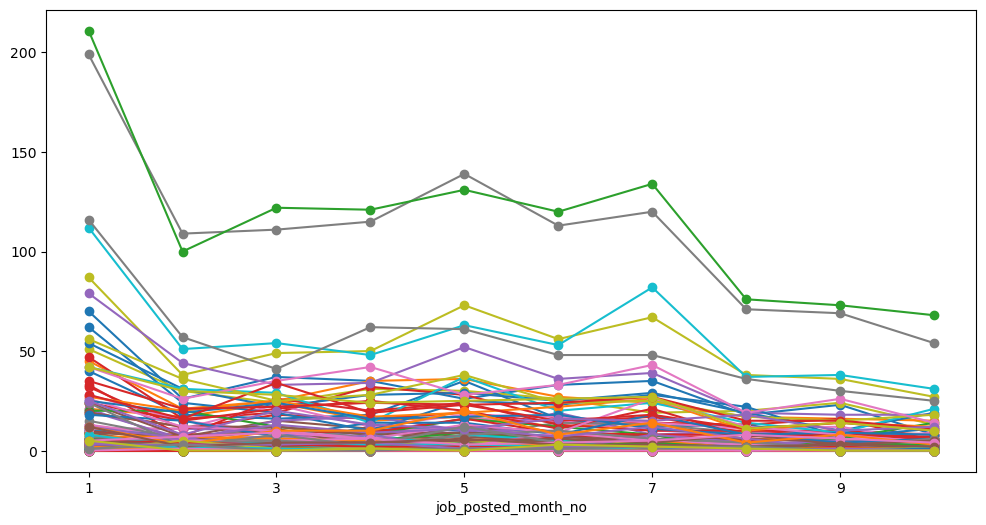

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

ax = df_plot.plot(kind='line', marker='o', figsize=(12, 6))
ax.get_legend().remove()
plt.show()
plt.tight_layout()
plt.show()

In [123]:
df_DE_Canada_percent = df_DE_Canada_pivot.div(DE_Totals/ 100, axis=0)

df_DE_Canada_percent

job_skills,airflow,alteryx,angular,ansible,asp.net,assembly,atlassian,aurora,aws,azure,...,visio,visual basic,vue,vue.js,watson,windows,word,xamarin,yarn,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,23.569024,0.336700,2.020202,0.000000,0.000000,0.3367,2.020202,0.673401,29.292929,37.710438,...,0.336700,0.000000,0.673401,0.000000,0.0,1.010101,4.040404,0.000000,0.336700,1.683502
2,16.774194,0.000000,3.225806,1.935484,0.000000,0.0000,0.000000,0.645161,24.516129,32.903226,...,1.290323,0.000000,0.000000,0.000000,0.0,1.935484,1.290323,0.645161,1.935484,0.000000
3,22.424242,1.818182,0.000000,1.818182,0.000000,0.0000,0.000000,1.212121,29.696970,32.727273,...,0.606061,0.000000,0.000000,0.000000,0.0,1.818182,2.424242,0.000000,0.000000,0.000000
4,21.875000,3.125000,0.000000,2.500000,0.000000,0.0000,0.000000,0.625000,31.250000,30.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,2.500000,2.500000,0.000000,0.000000,0.625000
5,14.054054,3.783784,2.162162,1.621622,0.000000,0.0000,0.540541,0.540541,39.459459,34.054054,...,0.000000,0.000000,0.000000,0.540541,0.0,0.540541,3.243243,0.000000,0.540541,0.000000
6,22.000000,2.666667,0.000000,1.333333,0.000000,0.0000,2.000000,0.000000,37.333333,35.333333,...,0.000000,0.000000,0.000000,0.000000,0.0,1.333333,2.000000,0.000000,0.666667,2.000000
7,20.231214,0.000000,0.000000,0.578035,0.000000,0.0000,0.578035,0.578035,38.728324,47.398844,...,1.156069,0.000000,0.000000,0.000000,0.0,1.156069,1.734104,0.000000,1.156069,1.156069
8,16.981132,0.000000,0.000000,0.943396,0.943396,0.0000,0.000000,0.000000,35.849057,34.905660,...,0.000000,1.886792,0.000000,0.000000,0.0,0.000000,1.886792,0.000000,1.886792,0.943396
9,23.958333,2.083333,0.000000,4.166667,0.000000,0.0000,0.000000,0.000000,37.500000,39.583333,...,0.000000,0.000000,0.000000,0.000000,0.0,1.041667,3.125000,0.000000,0.000000,0.000000


In [ ]:
df_DE_Canada_percent = df_DE_Canada_percent.reset_index()

df_DE_Canada_percent['job_posted_month'] = df_DE_Canada_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(int(x), format='%m').strftime('%b')if x != 'Totals' else x)
df_DE_Canada_percent = df_DE_Canada_percent.set_index('job_posted_month')
df_DE_Canada_percent = df_DE_Canada_percent.drop(columns='job_posted_month_no')

df_DE_Canada_percent

ValueError: cannot insert level_0, already exists

In [ ]:
df_DE_Canada_percent = df_DE_Canada_percent.reset_index(drop = True)

df_DE_Canada_percent['job_posted_month'] = (
    df_DE_Canada_percent['job_posted_month_no']
    .apply(lambda x: pd.to_datetime(int(x), format='%m').strftime('%b')
           if x != 'Total' else x)
)

df_DE_Canada_percent = df_DE_Canada_percent.set_index('job_posted_month')

df_DE_Canada_percent = df_DE_Canada_percent.drop(columns='job_posted_month_no')

df_DE_Canada_percent

job_skills,level_0,index,airflow,alteryx,angular,ansible,asp.net,assembly,atlassian,aurora,...,visio,visual basic,vue,vue.js,watson,windows,word,xamarin,yarn,zoom
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,0,0,23.569024,0.336700,2.020202,0.000000,0.000000,0.3367,2.020202,0.673401,...,0.336700,0.000000,0.673401,0.000000,0.0,1.010101,4.040404,0.000000,0.336700,1.683502
Feb,1,1,16.774194,0.000000,3.225806,1.935484,0.000000,0.0000,0.000000,0.645161,...,1.290323,0.000000,0.000000,0.000000,0.0,1.935484,1.290323,0.645161,1.935484,0.000000
Mar,2,2,22.424242,1.818182,0.000000,1.818182,0.000000,0.0000,0.000000,1.212121,...,0.606061,0.000000,0.000000,0.000000,0.0,1.818182,2.424242,0.000000,0.000000,0.000000
Apr,3,3,21.875000,3.125000,0.000000,2.500000,0.000000,0.0000,0.000000,0.625000,...,0.000000,0.000000,0.000000,0.000000,0.0,2.500000,2.500000,0.000000,0.000000,0.625000
May,4,4,14.054054,3.783784,2.162162,1.621622,0.000000,0.0000,0.540541,0.540541,...,0.000000,0.000000,0.000000,0.540541,0.0,0.540541,3.243243,0.000000,0.540541,0.000000
Jun,5,5,22.000000,2.666667,0.000000,1.333333,0.000000,0.0000,2.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,1.333333,2.000000,0.000000,0.666667,2.000000
Jul,6,6,20.231214,0.000000,0.000000,0.578035,0.000000,0.0000,0.578035,0.578035,...,1.156069,0.000000,0.000000,0.000000,0.0,1.156069,1.734104,0.000000,1.156069,1.156069
Aug,7,7,16.981132,0.000000,0.000000,0.943396,0.943396,0.0000,0.000000,0.000000,...,0.000000,1.886792,0.000000,0.000000,0.0,0.000000,1.886792,0.000000,1.886792,0.943396
Sep,8,8,23.958333,2.083333,0.000000,4.166667,0.000000,0.0000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,1.041667,3.125000,0.000000,0.000000,0.000000


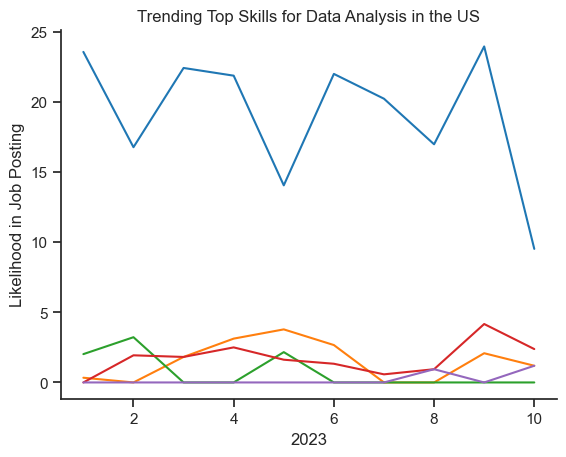

In [132]:
df_plot = df_DE_Canada_percent.iloc[:, :5]
df_plot = df_plot[df_plot.index != 'Total']

sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')
sns.despine()

plt.title('Trending Top Skills for Data Analysis in the US')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.legend().remove()

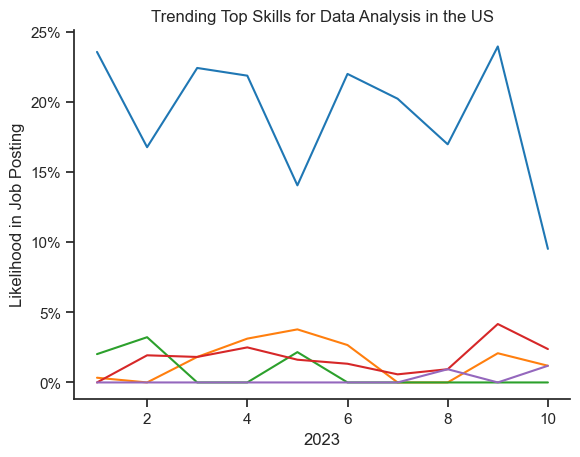

In [136]:
df_plot = df_DE_Canada_percent.iloc[:-1, :5]  # exclude last row (Total)

sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')
sns.despine()

plt.title('Trending Top Skills for Data Analysis in the US')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.legend().remove()

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

for i in range(5):
    plt.text(11, df_plot.iloc[-1, i], df_plot.columns[i])

